# 📂 STEP 1: Dataset Loading & EDA

In [1]:
# ============================================================
# 🚀 STEP 1: Dataset Loading & EDA
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine

# Load dataset
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

print('📂 Wine Dataset Loaded!')
print(f'Shape: {df.shape}')
print(f'Classes: {wine.target_names}')
df.head()

📂 Wine Dataset Loaded!
Shape: (178, 14)
Classes: ['class_0' 'class_1' 'class_2']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


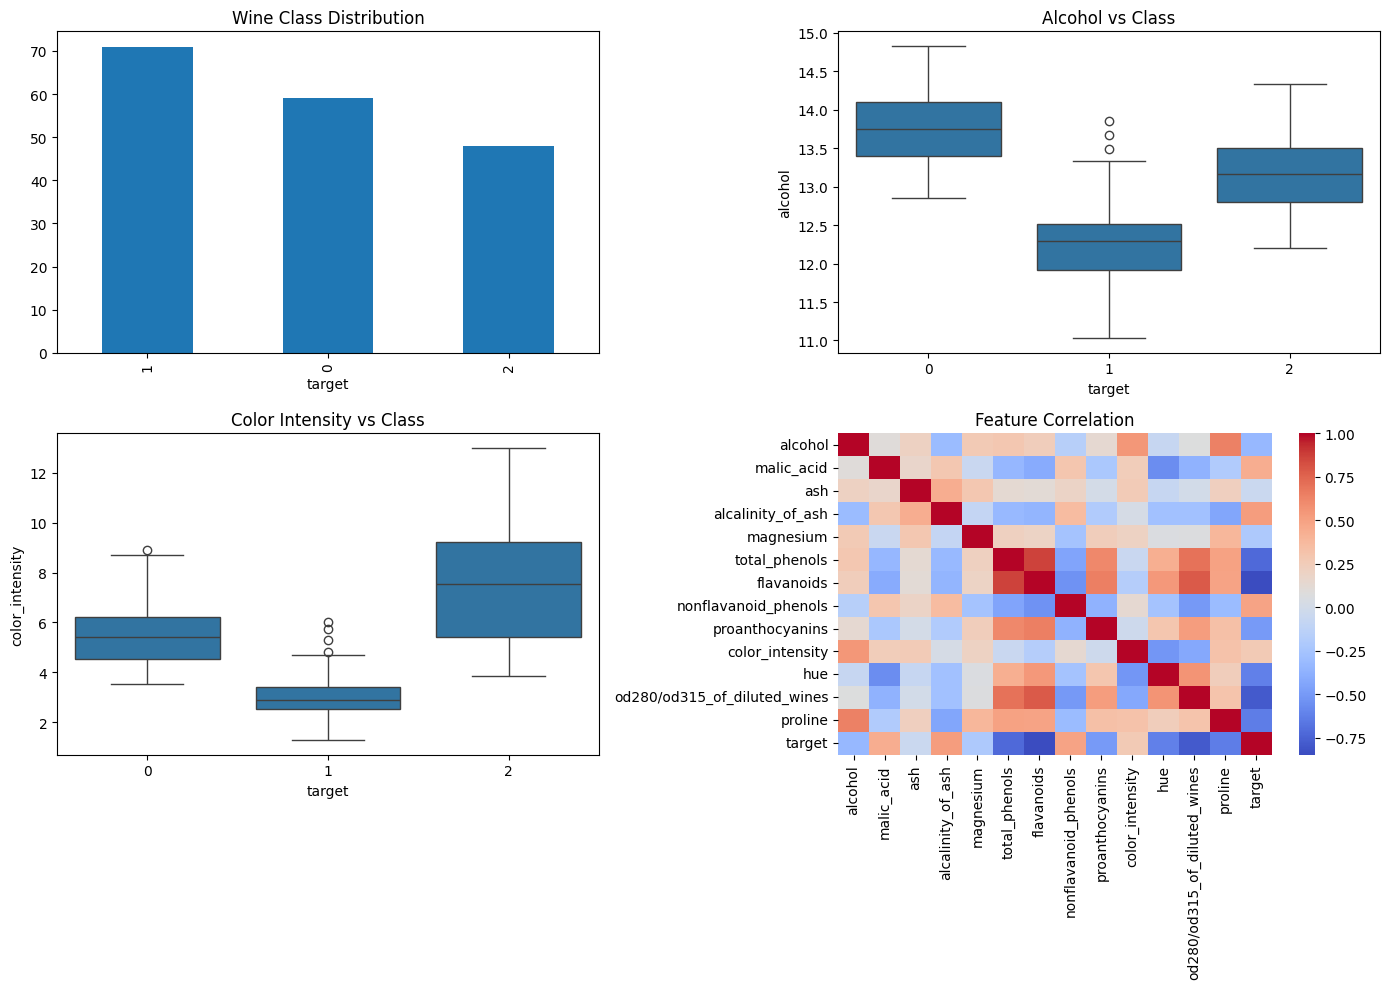

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Class distribution
df['target'].value_counts().plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title('Wine Class Distribution')

# Alcohol vs Class
sns.boxplot(x='target', y='alcohol', data=df, ax=axes[0,1])
axes[0,1].set_title('Alcohol vs Class')

# Color intensity vs Class
sns.boxplot(x='target', y='color_intensity', data=df, ax=axes[1,0])
axes[1,0].set_title('Color Intensity vs Class')

# Correlation heatmap
sns.heatmap(df.corr(), cmap='coolwarm', ax=axes[1,1])
axes[1,1].set_title('Feature Correlation')

plt.tight_layout()
plt.show()

# 🔧 STEP 2: Feature Engineering & Preprocessing

In [3]:
# ============================================================
# 🚀 STEP 2: Preprocessing
# ============================================================

from sklearn.preprocessing import StandardScaler

X = df.drop('target', axis=1)
y = df['target']

print("Missing values:\n", df.isnull().sum())

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nDataset shape: {X.shape}")

Missing values:
 alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

Dataset shape: (178, 13)


# 🤖 STEP 3: Model Training

In [4]:
# ============================================================
# 🚀 STEP 3: Model Training
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

X_tr, X_te, y_tr, y_te = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(),
    'SVM': SVC(probability=True),
    'KNN': KNeighborsClassifier()
}

results = {}

print('🚀 Training Models...')
print('---------------------------------------------------')

for name, model in models.items():
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    results[name] = {
        'model': model,
        'pred': y_pred,
        'acc': accuracy_score(y_te, y_pred),
        'prec': precision_score(y_te, y_pred, average='weighted'),
        'rec': recall_score(y_te, y_pred, average='weighted'),
        'f1': f1_score(y_te, y_pred, average='weighted')
    }

    print(f"{name}: Accuracy={results[name]['acc']:.4f}, F1={results[name]['f1']:.4f}")

🚀 Training Models...
---------------------------------------------------
Logistic Regression: Accuracy=0.9722, F1=0.9720
Random Forest: Accuracy=1.0000, F1=1.0000
SVM: Accuracy=0.9722, F1=0.9720
KNN: Accuracy=0.9722, F1=0.9724


# 📊 STEP 4: Evaluation (Confusion Matrix + ROC)


🏆 Best Model: Random Forest


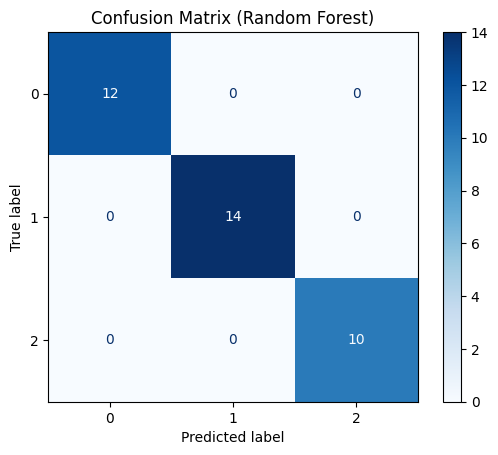

In [5]:
# ============================================================
# 🚀 STEP 4: Evaluation
# ============================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_name = max(results, key=lambda k: results[k]['f1'])
best_model = results[best_name]

print(f"\n🏆 Best Model: {best_name}")

cm = confusion_matrix(y_te, best_model['pred'])

ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title(f'Confusion Matrix ({best_name})')
plt.show()

# ⚙️ STEP 5: Hyperparameter Tuning

In [6]:
# ============================================================
# 🚀 STEP 5: Hyperparameter Tuning
# ============================================================

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10]
}

rf = RandomForestClassifier()

grid = GridSearchCV(rf, param_grid, cv=5, scoring='f1_weighted')
grid.fit(X_tr, y_tr)

print("Best Params:", grid.best_params_)

y_tuned = grid.best_estimator_.predict(X_te)

print("F1 Before:", results['Random Forest']['f1'])
print("F1 After :", f1_score(y_te, y_tuned, average='weighted'))

Best Params: {'max_depth': None, 'n_estimators': 50}
F1 Before: 1.0
F1 After : 1.0


# 🏆 STEP 6: Final Results Dashboard

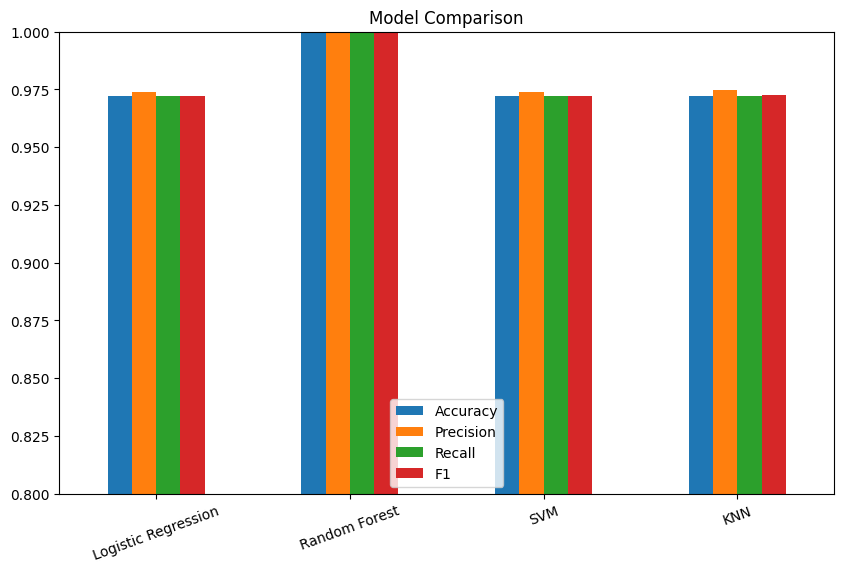

In [7]:
# ============================================================
# 🚀 FINAL RESULTS
# ============================================================

summary = pd.DataFrame({
    name: [res['acc'], res['prec'], res['rec'], res['f1']]
    for name, res in results.items()
}, index=['Accuracy', 'Precision', 'Recall', 'F1'])

summary.T.plot(kind='bar', figsize=(10,6))
plt.title('Model Comparison')
plt.ylim(0.8, 1.0)
plt.xticks(rotation=20)
plt.show()